In [1]:
# Importation for the libraries i need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Nairobi_feature_engineered_dataset.csv")
df.head()

,location,timestamp,P0,P1,P2,humidity,temperature,P0_lag_1h,P0_lag_2h,P0_lag_3h,...,P1_lag_3h,P2_lag_1h,P2_lag_2h,P2_lag_3h,humidity_lag_1h,humidity_lag_2h,humidity_lag_3h,temperature_lag_1h,temperature_lag_2h,temperature_lag_3h
0,76,2026-01-01 18:00:00+00:00,13.25,23.15,20.95,2.520,-0.710,11.50,7.40,5.25,...,9.25,18.30,12.75,8.1875,5.675,5.890,3.291667,-1.035,-1.42125,-0.227083
1,76,2026-01-01 19:00:00+00:00,16.80,29.10,26.15,3.075,-0.825,13.25,11.50,7.40,...,14.65,20.95,18.30,12.7500,2.520,5.675,5.890000,-0.710,-1.03500,-1.421250
2,76,2026-01-01 20:00:00+00:00,14.80,26.10,24.15,2.555,-0.280,16.80,13.25,11.50,...,20.50,26.15,20.95,18.3000,3.075,2.520,5.675000,-0.825,-0.71000,-1.035000
3,76,2026-01-01 21:00:00+00:00,11.35,20.30,18.75,1.005,-0.065,14.80,16.80,13.25,...,23.15,24.15,26.15,20.9500,2.555,3.075,2.520000,-0.280,-0.82500,-0.710000
4,76,2026-01-01 22:00:00+00:00,9.15,17.25,15.30,1.015,-0.265,11.35,14.80,16.80,...,29.10,18.75,24.15,26.1500,1.005,2.555,3.075000,-0.065,-0.28000,-0.825000


In [3]:
df.head()

,location,timestamp,P0,P1,P2,humidity,temperature,P0_lag_1h,P0_lag_2h,P0_lag_3h,...,P1_lag_3h,P2_lag_1h,P2_lag_2h,P2_lag_3h,humidity_lag_1h,humidity_lag_2h,humidity_lag_3h,temperature_lag_1h,temperature_lag_2h,temperature_lag_3h
0,76,2026-01-01 18:00:00+00:00,13.25,23.15,20.95,2.520,-0.710,11.50,7.40,5.25,...,9.25,18.30,12.75,8.1875,5.675,5.890,3.291667,-1.035,-1.42125,-0.227083
1,76,2026-01-01 19:00:00+00:00,16.80,29.10,26.15,3.075,-0.825,13.25,11.50,7.40,...,14.65,20.95,18.30,12.7500,2.520,5.675,5.890000,-0.710,-1.03500,-1.421250
2,76,2026-01-01 20:00:00+00:00,14.80,26.10,24.15,2.555,-0.280,16.80,13.25,11.50,...,20.50,26.15,20.95,18.3000,3.075,2.520,5.675000,-0.825,-0.71000,-1.035000
3,76,2026-01-01 21:00:00+00:00,11.35,20.30,18.75,1.005,-0.065,14.80,16.80,13.25,...,23.15,24.15,26.15,20.9500,2.555,3.075,2.520000,-0.280,-0.82500,-0.710000
4,76,2026-01-01 22:00:00+00:00,9.15,17.25,15.30,1.015,-0.265,11.35,14.80,16.80,...,29.10,18.75,24.15,26.1500,1.005,2.555,3.075000,-0.065,-0.28000,-0.825000


# ACF(Autocorrelation function) and PACF(Partial Autocorrelation Function)

This are used in time series modelling to establish if there is a correlation between an obseravtion and ita lags

**ACF vs PACF**
>
> - **ACF (Autocorrelation Function)**: Correlation between $y_t$ and
>   $y_{t-k}$ for all lags $k$
> - **PACF (Partial Autocorrelation Function)**: Correlation between
>   $y_t$ and $y_{t-k}$ after removing effects of intermediate lags


The ACF is a progressive addition of the pearson co-effiecient while for PACF it calculates the error terms between lags

	​



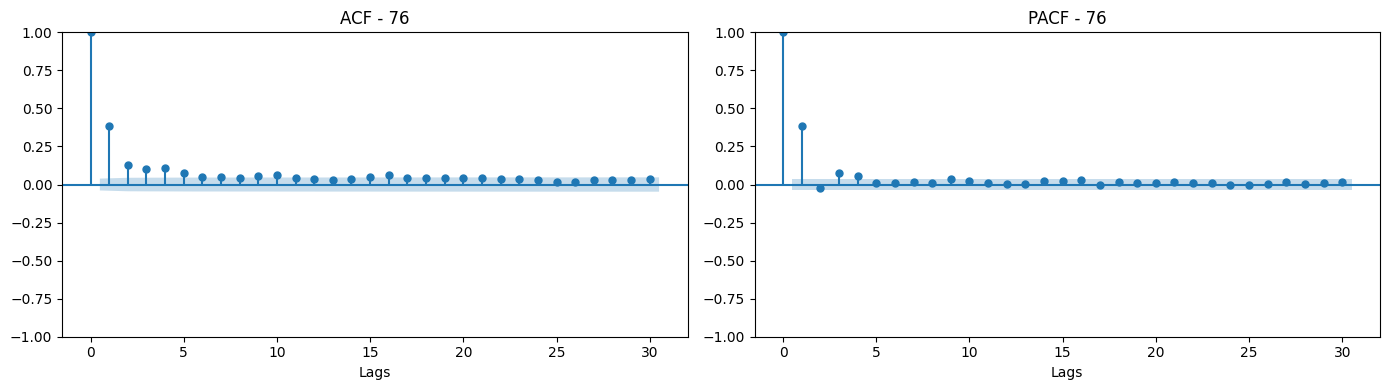

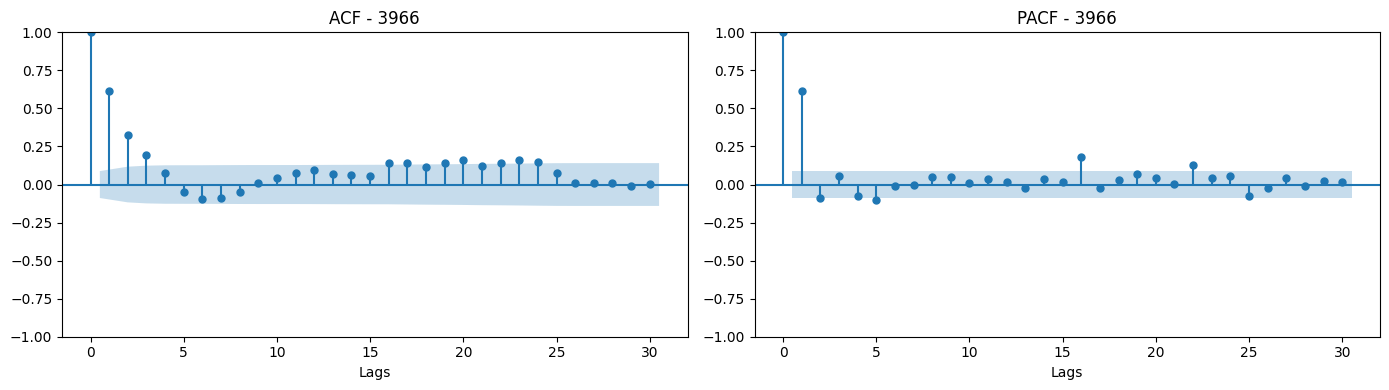

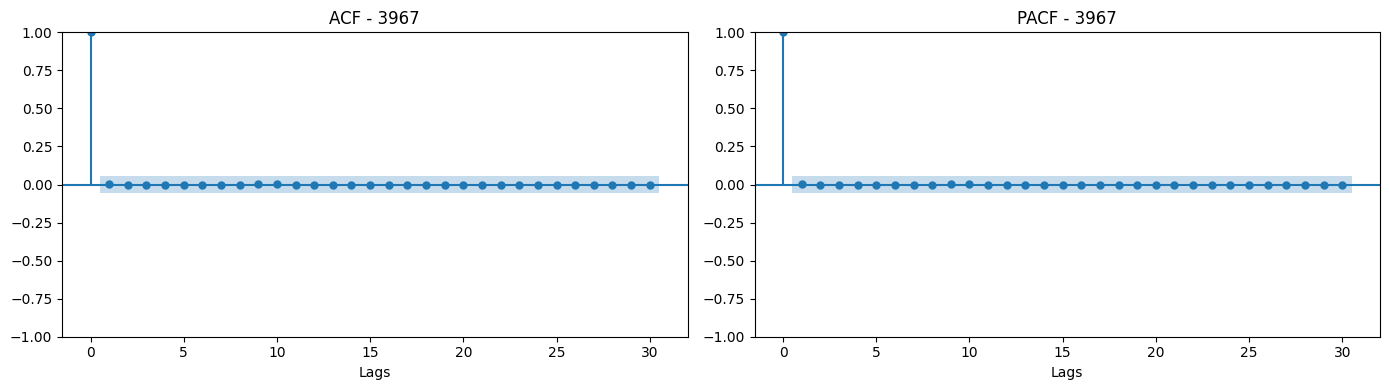

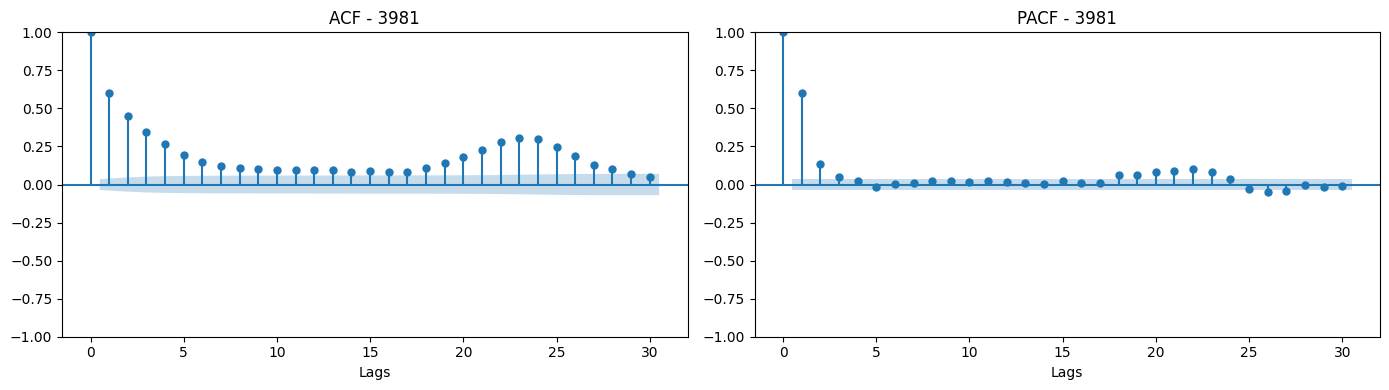

In [4]:

unique_locations = df["location"].unique()


for loc in unique_locations:

    loc_data = df[df["location"] == loc]["P2"].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))


    plot_acf(loc_data, ax=axes[0], lags=30)
    axes[0].set_title(f"ACF - {loc}")
    axes[0].set_xlabel("Lags")


    plot_pacf(loc_data, ax=axes[1], lags=30)
    axes[1].set_title(f"PACF - {loc}")
    axes[1].set_xlabel("Lags")


    plt.tight_layout()
    plt.show()

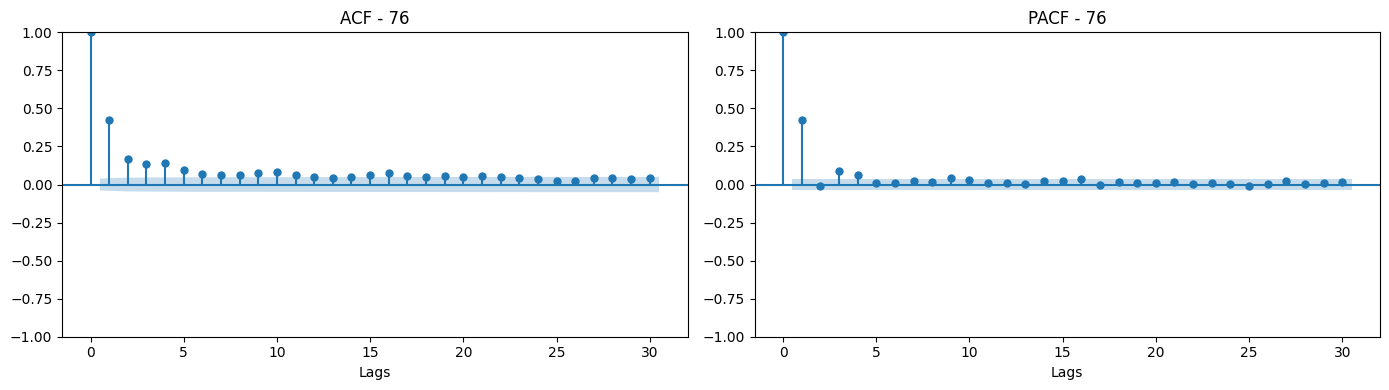

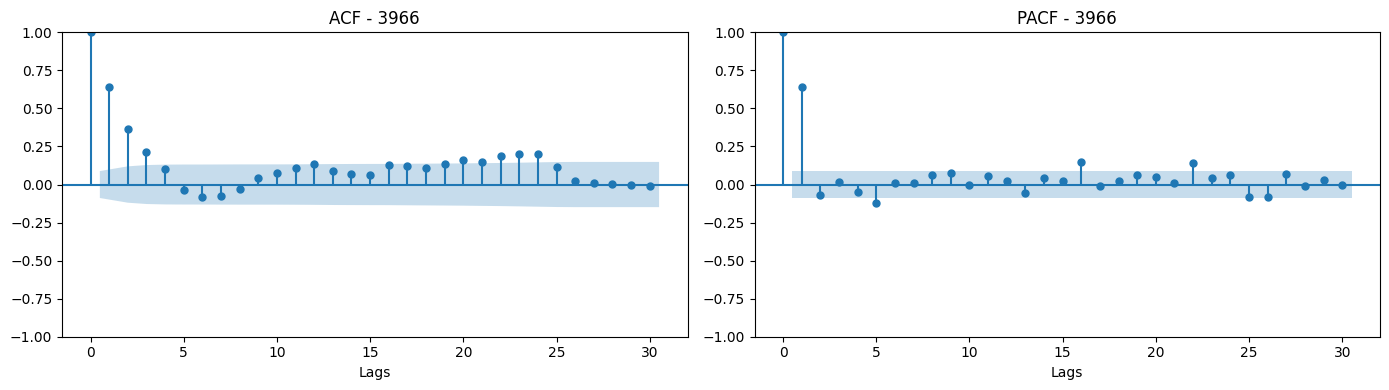

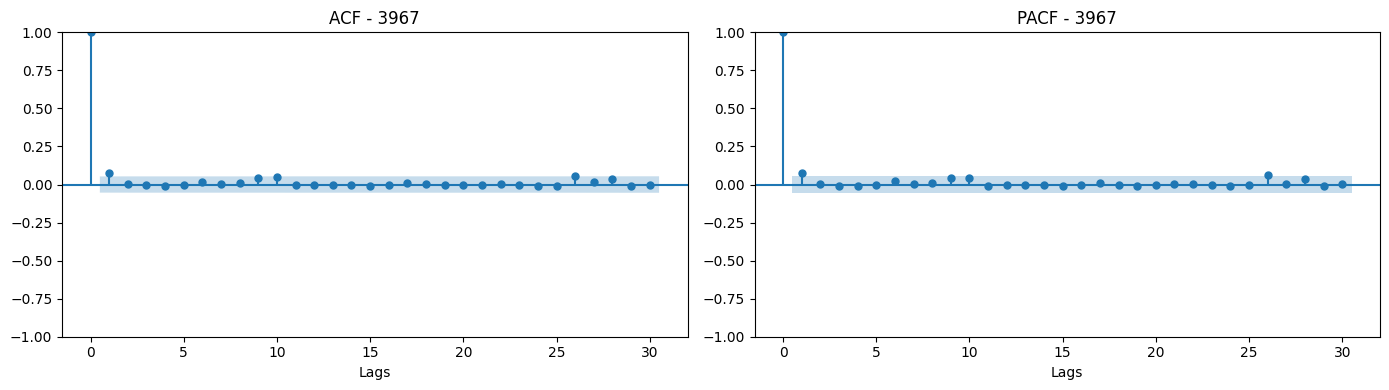

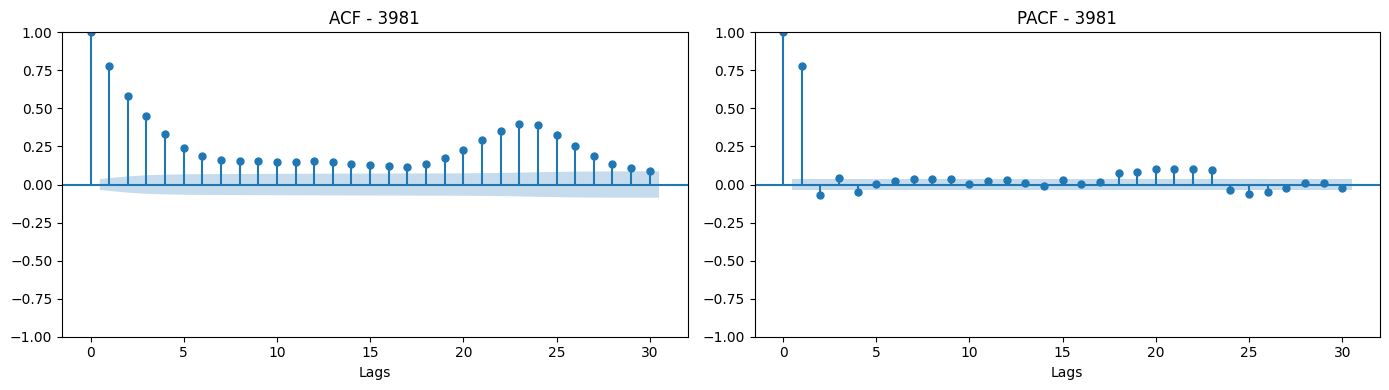

In [5]:
unique_locations = df["location"].unique()

for loc in unique_locations:
  loc_data = df[df["location"] == loc]["P1"].dropna()
  fig, axes = plt.subplots(1,2 , figsize=(14,4))

  plot_acf(loc_data,ax=axes[0], lags=30)
  axes[0].set_title(f"ACF - {loc}")
  axes[0].set_xlabel("Lags")

  plot_pacf(loc_data,ax=axes[1], lags=30)
  axes[1].set_title(f"PACF - {loc}")
  axes[1].set_xlabel("Lags")

  plt.tight_layout()
  plt.show()

In [6]:
df.columns

Index(['location', 'timestamp', 'P0', 'P1', 'P2', 'humidity', 'temperature',
       'P0_lag_1h', 'P0_lag_2h', 'P0_lag_3h', 'P1_lag_1h', 'P1_lag_2h',
       'P1_lag_3h', 'P2_lag_1h', 'P2_lag_2h', 'P2_lag_3h', 'humidity_lag_1h',
       'humidity_lag_2h', 'humidity_lag_3h', 'temperature_lag_1h',
       'temperature_lag_2h', 'temperature_lag_3h'],
      dtype='object')

In [7]:

location_dummies = pd.get_dummies(df['location'], prefix='location', prefix_sep='_', dtype=int)

df = pd.concat([df, location_dummies], axis=1)


location_cols = ["location_76", "location_3966", "location_3967", "location_3981"]


for var in ["humidity", "temperature"]:
    df[f"{var}_diff"] = df.groupby(location_cols)[var].diff()


df = df.dropna().reset_index(drop=True)

In [8]:
df.columns

Index(['location', 'timestamp', 'P0', 'P1', 'P2', 'humidity', 'temperature',
       'P0_lag_1h', 'P0_lag_2h', 'P0_lag_3h', 'P1_lag_1h', 'P1_lag_2h',
       'P1_lag_3h', 'P2_lag_1h', 'P2_lag_2h', 'P2_lag_3h', 'humidity_lag_1h',
       'humidity_lag_2h', 'humidity_lag_3h', 'temperature_lag_1h',
       'temperature_lag_2h', 'temperature_lag_3h', 'location_76',
       'location_3966', 'location_3967', 'location_3981', 'humidity_diff',
       'temperature_diff'],
      dtype='object')

In [9]:
df.drop(["humidity","temperature"], axis=1, inplace=True)

# Feature and Target splits

In [10]:
y_cols = ["P0", "P1", "P2", "humidity_diff", "temperature_diff"]
y = df[y_cols].values


x_cols = [
    "P0_lag_1h",
    "P1_lag_2h",
    "P2_lag_2h",
    "humidity_lag_2h",
    "temperature_lag_2h",
    "P1_lag_1h",
    "P2_lag_1h",
    "humidity_lag_1h",
    "temperature_lag_1h",
    "location_76",
    "location_3966",
    "location_3967",
    "location_3981",
]
X = df[x_cols].values

# Chronological Time Split

In [11]:
split_idx = int(len(X) * 0.80)


X_train = X[:split_idx]
X_val = X[split_idx:]


y_train = y[:split_idx]
y_val = y[split_idx:]

print("--- Chronological Split Complete ---")
print(f"Training set:   X_train shape = {X_train.shape} | y_train shape = {y_train.shape}")
print(f"Validation set: X_val shape   = {X_val.shape}  | y_val shape   = {y_val.shape}")

--- Chronological Split Complete ---
Training set:   X_train shape = (5890, 13) | y_train shape = (5890, 5)
Validation set: X_val shape   = (1473, 13)  | y_val shape   = (1473, 5)


# Glorot/Xavier Initialization

Glorot initialization calculates a specific, safe boundary tailored to your exact data structure.

Instead of guessing a range, it sets the random weight boundaries using this formula:

$$\(\pm \sqrt{\frac{6}{\text{num\_features}+\text{num\_targets}}}\)\$$

For your specific setup with 9 features and 5 targets, the math works out perfectly to prevent overflow:

$$
\pm \sqrt{\frac{6}{9+5}}
=
\pm \sqrt{\frac{6}{14}}
\approx
\pm 0.6546
$$

In [12]:
# matrix dimensions
num_samples, num_features = X_train.shape
_, num_targets = y_train.shape

# Hyperparameters
learning_rate = 0.001
epochs = 500


init_range = np.sqrt(6.0 / (num_features + num_targets))
np.random.seed(42)

W = np.random.uniform(-init_range, init_range, size=(num_features, num_targets))
b = np.zeros((1, num_targets))

print("--- Optimization Parameters Initialized ---")
print(f"Weight Matrix (W) Shape: {W.shape}  -> (9 features x 5 targets)")
print(f"Bias Vector (b) Shape:   {b.shape}  -> (1 x 5 targets)")

--- Optimization Parameters Initialized ---
Weight Matrix (W) Shape: (13, 5)  -> (9 features x 5 targets)
Bias Vector (b) Shape:   (1, 5)  -> (1 x 5 targets)


In [13]:
# Base Dimensions Initialization
num_features = X_train.shape[1]
num_targets = y_train.shape[1]
total_features = num_features + num_targets  #  (Lags + MA Errors)


np.random.seed(42)
W = np.random.uniform(-0.01, 0.01, size=(total_features, num_targets))
b = np.zeros((1, num_targets))

# Parameters
learning_rate = 0.0005
epochs = 500
errors_train = np.zeros_like(y_train)

print(" Executing NaN-safe training loop architecture...")

for epoch in range(1, epochs + 1):
    # Construct the Moving Average shock feature (shift previous errors down)
    error_lag_train = np.zeros_like(errors_train)
    error_lag_train[1:] = errors_train[:-1]

    # Horizontally stack features: [Base Features + MA Error Lags] -> Shape: (N, 14)
    X_full_train = np.hstack((X_train, error_lag_train))

    # Linear Prediction Pass
    y_pred = np.dot(X_full_train, W) + b

    # Residual Calculation
    errors_train = y_train - y_pred
    loss = np.mean(errors_train**2)

    # Gradient Evaluation
    N = X_full_train.shape[0]
    dW = -(2 / N) * np.dot(X_full_train.T, errors_train)
    db = -(2 / N) * np.sum(errors_train, axis=0, keepdims=True)

    #Gradient clipping blocks explosive accumulation and NaNs
    dW = np.clip(dW, -5.0, 5.0)
    db = np.clip(db, -5.0, 5.0)

    # Matrix Parameter Updates
    W -= learning_rate * dW
    b -= learning_rate * db

    if epoch == 1 or epoch % 100 == 0:
        print(f"Epoch {epoch:03d}/{epochs} | Training Loss (MSE): {loss:.4f}")

print(" Training run completed successfully.")

 Executing NaN-safe training loop architecture...
Epoch 001/500 | Training Loss (MSE): 348.0783
Epoch 100/500 | Training Loss (MSE): 92.8070
Epoch 200/500 | Training Loss (MSE): 80.9383
Epoch 300/500 | Training Loss (MSE): 76.8434
Epoch 400/500 | Training Loss (MSE): 76.3237
Epoch 500/500 | Training Loss (MSE): 75.9180
 Training run completed successfully.


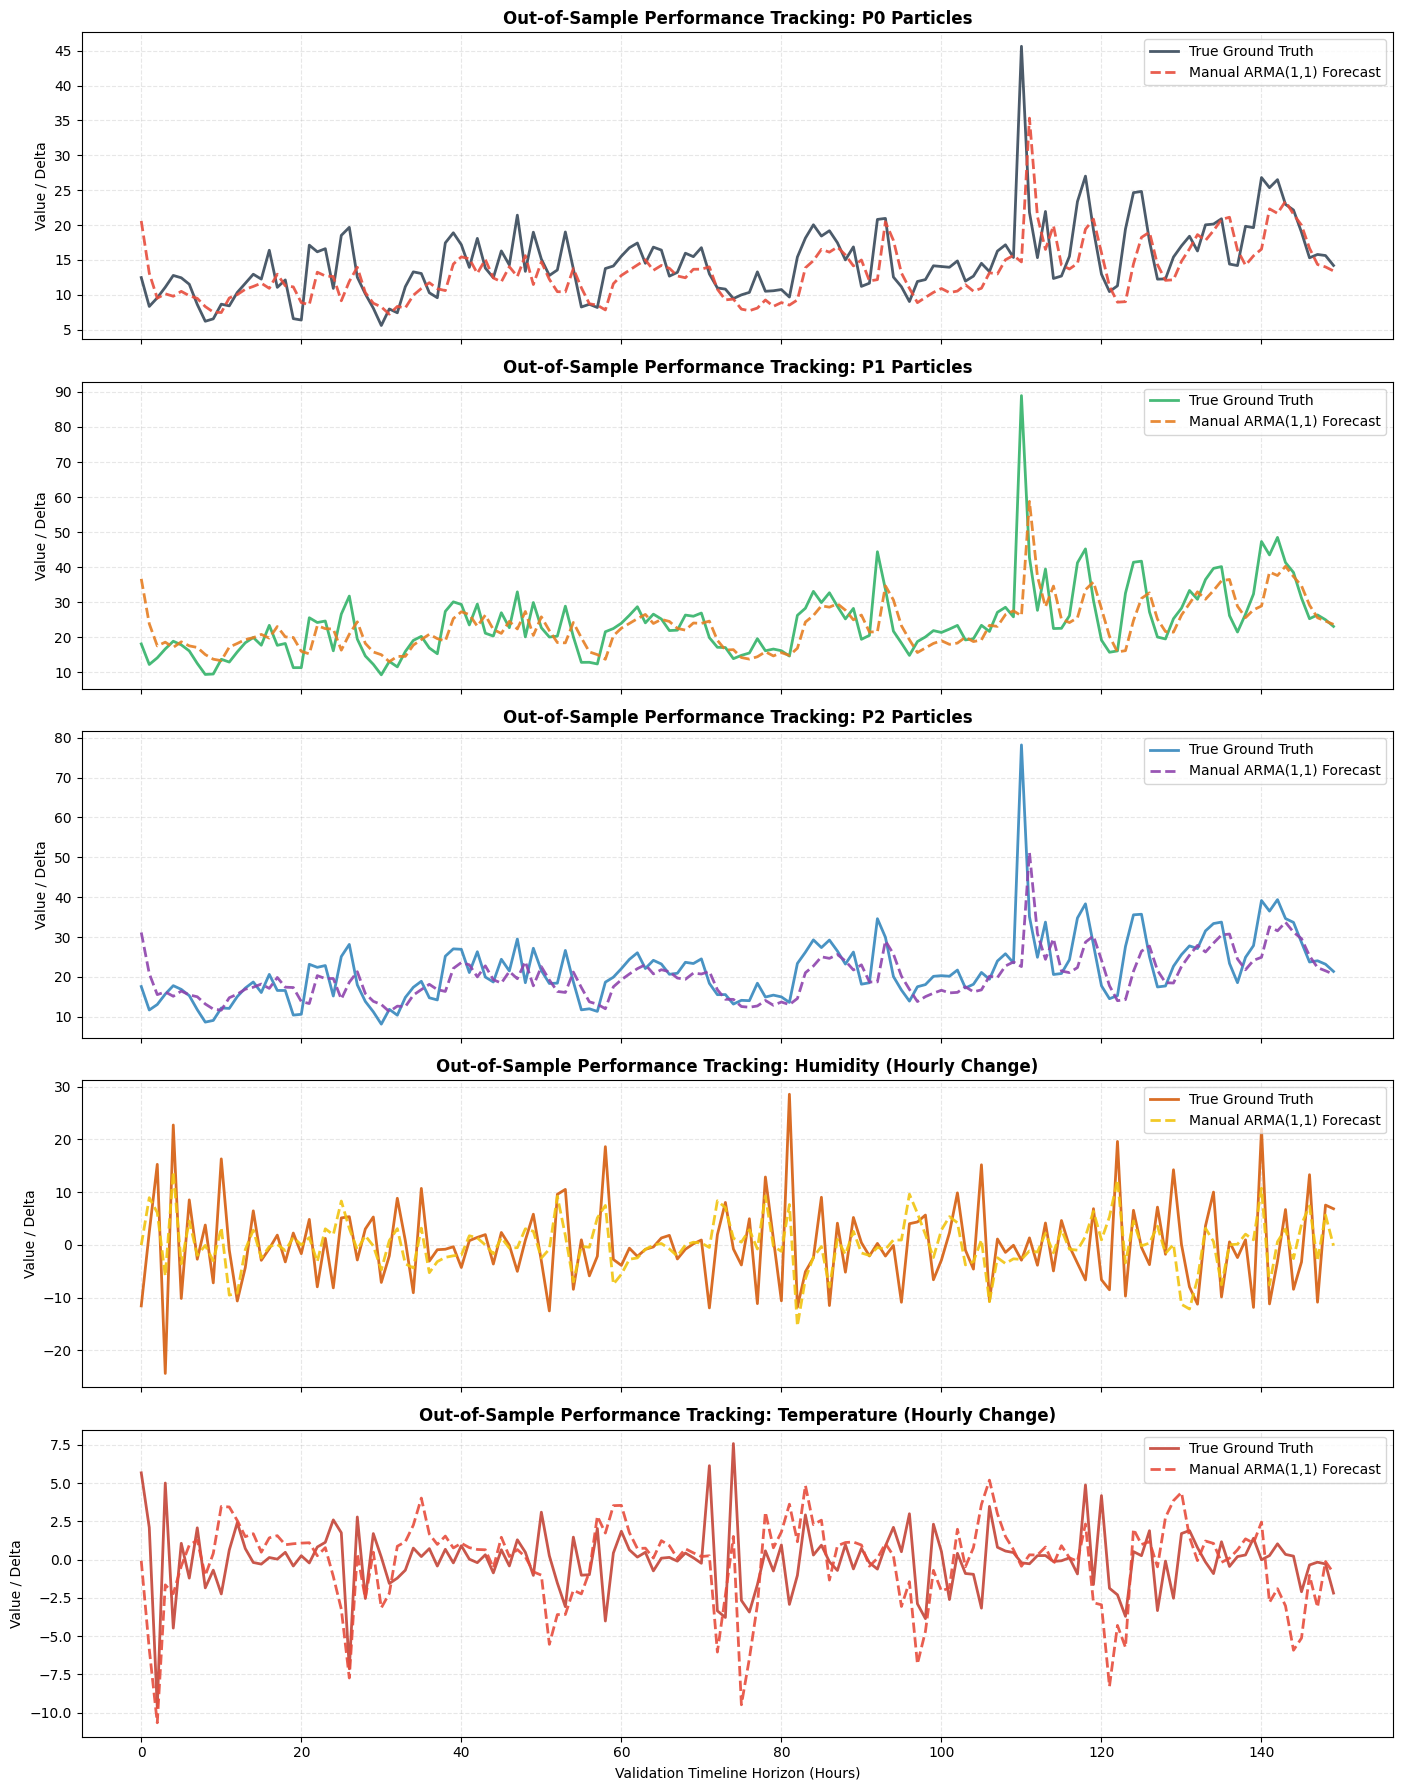

In [14]:
num_val_samples = X_val.shape[0]
y_pred_val = np.zeros_like(y_val)
last_error = np.zeros(num_targets)

for t in range(num_val_samples):
    full_features_t = np.hstack((X_val[t].flatten(), last_error.flatten()))
    pred_t = np.dot(full_features_t, W) + b
    y_pred_val[t] = pred_t.flatten()
    last_error = y_val[t] - pred_t.flatten()

# 2. Set up a 5-panel visualization layout for all targets in matrix y
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

# Map all 5 indices: P0, P1, P2, humidity_diff, temperature_diff
targets_to_plot = [0, 1, 2, 3, 4]
colors_real = ["#2c3e50", "#27ae60", "#2980b9", "#d35400", "#c0392b"]
colors_pred = ["#e74c3c", "#e67e22", "#8e44ad", "#f1c40f", "#e74c3c"]
labels = [
    "P0 Particles",
    "P1 Particles",
    "P2 Particles",
    "Humidity (Hourly Change)",
    "Temperature (Hourly Change)",
]

# Plotting window horizon (150 hours for crisp scannability)
plot_horizon = min(150, num_val_samples)
time_axis = np.arange(plot_horizon)

for idx, target_idx in enumerate(targets_to_plot):
    ax = axes[idx]

    # Ground Truth row from y_val
    ax.plot(
        time_axis,
        y_val[:plot_horizon, target_idx],
        label="True Ground Truth",
        color=colors_real[idx],
        linewidth=2,
        alpha=0.85,
    )

    # Forecast row from our vector ARMA predictions
    ax.plot(
        time_axis,
        y_pred_val[:plot_horizon, target_idx],
        label="Manual ARMA(1,1) Forecast",
        color=colors_pred[idx],
        linewidth=2,
        linestyle="--",
        alpha=0.9,
    )

    ax.set_title(
        f"Out-of-Sample Performance Tracking: {labels[idx]}",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_ylabel("Value / Delta")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(loc="upper right")

# Unified time axis label at the baseline
axes[-1].set_xlabel("Validation Timeline Horizon (Hours)")

plt.tight_layout()
plt.show()
